In [2]:
import pandas as pd
import numpy as np

# carico dataset normale
#df = pd.read_pickle("D:/dataset_M1_M20_30_08_2026.pkl")
yymmdd = '240910'
pkl1 = f"C:/Users/mstefano/Desktop/Mattia_STEFANO/disco_D_Kingston/dataset_{yymmdd}_M1_M40_08_09_2026.pkl"

df = pd.read_pickle(pkl1)


# carico dataset sanity check


pkl2_sc = f"C:/Users/mstefano/Desktop/Mattia_STEFANO/disco_D_Kingston/dataset_{yymmdd}_M1_M40_08_09_2026_sanity_check.pkl"

df_sc = pd.read_pickle(pkl2_sc)


In [3]:
# label matrici
main_matrix_ids = []
for i in range(1,41):
    name_m = 'M' + str(i)
    main_matrix_ids.append(name_m)

mm1 = []
for i in range(1,21):
    id = str(i)
    m_id = 'M' + id
    mm1.append(m_id)
mm2 = []
for i in range(21,41):
    id = str(i)
    m_id = 'M' + id
    mm2.append(m_id)




### calcolo le distanze per il primo caso

In [4]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:

        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp[(SpineType, mm, 'experiment')] = aus_distances


In [5]:
spine_types = ['BLA', 'CA3']
# main_matrix_ids = ['mm3'] # , 'mm4', 'mm5', 'mm6', 'mm7']

cond = ['random']
# spine_types
# main_matrix_ids
distances_sim = {}
ref_Vs = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:

        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim[(SpineType, mm, 'random')] = aus_distances


### Calcolo delle distanze per il sanity check

In [6]:
distances_exp_sc = {}
ref_Vs_sc = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:


        aus_data = df_sc.loc[
            (df_sc["spine_type"] == SpineType) &
            (df_sc["main_matrix_id"] == mm) &
            (df_sc["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs_sc[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp_sc[(SpineType, mm, 'experiment')] = aus_distances


In [8]:

distances_sim_sc = {}
ref_Vs_sc = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:

        aus_data = df_sc.loc[
            (df_sc["spine_type"] == SpineType) &
            (df_sc["main_matrix_id"] == mm) &
            (df_sc["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs_sc[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs_sc[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim_sc[(SpineType, mm, 'random')] = aus_distances


In [9]:
#distances_sim_sc

In [10]:
# aggiunte 04 09 2026
regions =  ['BLA', 'CA3']
all_mms = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
for i in range(1,41):
    id = str(i)
    m_id = 'M' + id
    all_mms.append(m_id)

dati = {}
x0 = 1.0
dist_norm = {}
dist_norm_sc = {}
kde = {}
for i, mm in enumerate(all_mms):
    for j, region in enumerate(regions):

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

        # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        #d_exp = exp_data / mu
        d_exp = exp_data/ mu

        # ----- sanity check
        random_data_sc = np.array(
            distances_sim_sc[region, mm, 'random']
        )
        exp_data_sc = np.array(
            distances_exp_sc[region, mm, 'experiment']
        )

        # media random
        mu_sc = np.mean(random_data_sc)

        # normalizzazione
        d_sim_sc = random_data_sc / mu_sc
        #d_exp = exp_data / mu
        d_exp_sc = exp_data_sc/ mu_sc




        #dist_norm
        dist_norm[region, mm,'random'] = d_sim
        dist_norm[region,mm,'experiment'] = d_exp # shift_multiplo_da_dati(x0,d_exp)
        #dist_norm
        dist_norm_sc[region, mm,'random'] = d_sim_sc
        dist_norm_sc[region,mm,'experiment'] = d_exp_sc # shift_multiplo_da_dati(x0,d_exp)


In [11]:
dist_norm_sc['BLA', 'M1','experiment']


array([1.05508859, 0.88787944, 0.97460286, 1.06369088, 0.94355154,
       0.94098131, 0.93427591, 1.01707127, 0.94445886, 0.84804356,
       1.06141847, 1.01602268, 0.97496479, 1.00493834, 1.00792904,
       0.95370645, 1.04510384, 1.05948623, 0.96187893, 1.01444254,
       1.06155782, 0.97579143, 1.08770795, 0.97983554, 0.99480806,
       0.97506711, 0.9677428 , 1.06113936, 1.03076622, 0.99362757,
       1.01813424, 1.01691767, 1.06366834, 0.97900829, 1.06105402,
       0.93641791, 0.94638352, 1.01355833, 0.98318685, 1.02066215,
       1.02119679, 0.99088137, 1.0573238 , 0.93846124, 1.01688077,
       1.01930094, 0.90910092, 1.01465718])

In [12]:
"""
Lo shift lo definisco come posizione del picco della KDE
"""
from scipy.stats import gaussian_kde

def picco_kde_da_dati(dati, n_punti_valutazione=5000):
    """
    Calcolo la KDE dei dati come in seaborn e trovo la posizione del suo picco
    n_punti_valutazione ---> Risoluzione della griglia su cui si valuta la KDE: piu' punti = stima del picco piu' precisa.
    """
    dati = np.asarray(dati)
    kde = gaussian_kde(dati) # ----- kde

    # Griglia di valutazione
    margine = 0.1 * (dati.max() - dati.min())
    x_grid = np.linspace(dati.min() - margine, dati.max() + margine, n_punti_valutazione)
    y_grid = kde(x_grid)

    x_picco = x_grid[np.argmax(y_grid)] # ----- posizione del picco della curva

    return x_picco, kde,x_grid




In [13]:
distr = {}
conditions = ['experiment', 'random']
risultati = {}
risultati_sc = {}
x0 = 1.0
for (area, matrice, condition), dn in dist_norm.items():

    name = f'{area}_{matrice}_{condition}'
    #distr[name] = dn
    risultati[area,matrice,condition] = picco_kde_da_dati(dn)


risultati.keys()

for (area, matrice, condition), dn in dist_norm_sc.items():

    name = f'{area}_{matrice}_{condition}'
    #distr[name] = dn
    risultati_sc[area,matrice,condition] = picco_kde_da_dati(dn)



risultati_sc['BLA','M1','random']


(np.float64(1.017849036720498),
 array([0.72868937, 0.72877679, 0.7288642 , ..., 1.1654883 , 1.16557571,
        1.16566312], shape=(5000,)))

In [14]:
risultati_sc['BLA','M1','experiment'][0]

np.float64(1.0075433524062958)

In [39]:
shift_BLA = {}
shift_CA3 = {}

shift_BLA_sc = {}
shift_CA3_sc = {}

for i in range(1,41):
    matrix_name = 'M' + str(i)
    shift_BLA['BLA',matrix_name] = risultati['BLA',matrix_name,'experiment'][0] - risultati['BLA',matrix_name,'random'][0]
    shift_CA3['CA3', matrix_name] = risultati['CA3',matrix_name,'experiment'][0] - risultati['CA3', matrix_name,'random'][0]

    shift_BLA_sc['BLA',matrix_name] = risultati_sc['BLA',matrix_name,'experiment'][0] - risultati_sc['BLA',matrix_name,'random'][0]
    shift_CA3_sc['CA3', matrix_name] = risultati_sc['CA3',matrix_name,'experiment'][0] - risultati_sc['CA3', matrix_name,'random'][0]


#print(shift_BLA_sc)

#### Plot per ogni Main matrix di (shift_BLA, shift_CA3)

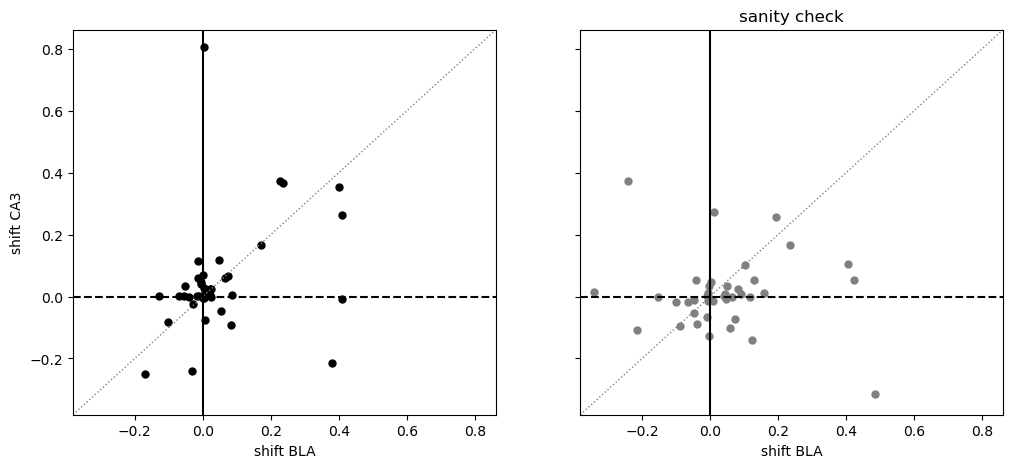

In [40]:
#plt.figure(figursize= (10,10))
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,5),sharey=True,sharex=True)
#print(all_mms)
for m in all_mms:
    x = shift_BLA['BLA',m]
    y  = shift_CA3['CA3',m]

    x_sc = shift_BLA_sc['BLA',m]
    y_sc = shift_CA3_sc['CA3',m]

    #if m in ['M1', 'M4', 'M6','M11','M14','M17','M7']:
    #    mark = '>'
    #elif m in ['M2', 'M3', 'M9', 'M15', 'M16', 'M18','M10']:
    #    mark = '<'
    #else:
    #    mark = '.'
    #plt.plot(x,y,mark,label=m)
    axes[0].plot(x,y,'.k',markersize=10)
    axes[1].plot(x_sc,y_sc,'.',color='grey',markersize=10)

axes[1].set_title('sanity check')
axes[0].set_xlabel('shift BLA')
axes[1].set_xlabel('shift BLA')
axes[0].set_ylabel('shift CA3')

for ax in axes:
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        color='gray',
        linestyle=':',
        linewidth=1
    )

    # stessi limiti su x e y
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.axhline(0,color='k',linestyle='--')
    ax.axvline(0, color='k')

'''
ax = plt.gca()
lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color='gray', linewidth=0.8, linestyle=':', label='y = x')
plt.title('Main matrix id')
plt.xlabel('shift BLA')
plt.ylabel('shift CA3')
#plt.legend()
'''
plt.show()

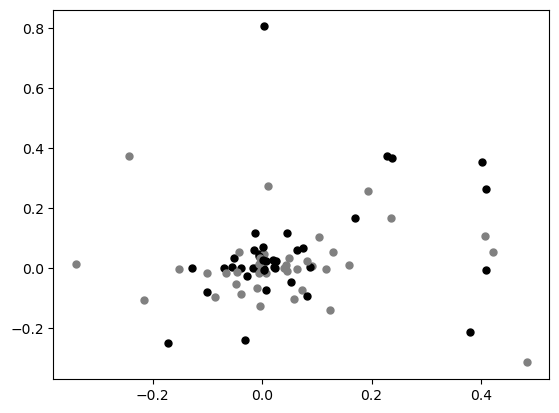

In [18]:
x_arr = []
y_arr = []
x_sc_arr = []
y_sc_arr = []

for m in all_mms:
    x = shift_BLA['BLA',m]
    y  = shift_CA3['CA3',m]

    x_sc = shift_BLA_sc['BLA',m]
    y_sc = shift_CA3_sc['CA3',m]

    x_arr.append(x)
    y_arr.append(y)
    x_sc_arr.append(x_sc)
    y_sc_arr.append(y_sc)

    plt.plot(x,y,'.k',markersize=10)
    plt.plot(x_sc,y_sc,'.',color='grey',markersize=10)

In [19]:
from scipy.stats import pearsonr
r,p = pearsonr(x_arr,y_arr)
r_sc,p_sc = pearsonr(x_sc_arr,y_sc_arr)

In [20]:
print(r,p)

print(r_sc,p_sc)

0.3266023885315008 0.03969579716690692
-0.09604874349046763 0.5554799014019394


### Metodo Bootstrap sugli shift, fit lineare e calcolo delle slopes

In [21]:
# Bootstrap
x_arr = np.asarray(x_arr, dtype=np.float64)
y_arr = np.asarray(y_arr, dtype=np.float64)
x_sc_arr = np.asarray(x_sc_arr, dtype=np.float64)
y_sc_arr = np.asarray(y_sc_arr, dtype=np.float64)

from scipy.stats import linregress

def bootstrap_slopes(x, y, N=1000, seed=None):
    """
    x, y: array di punti (stessa lunghezza)
    N: numero di campioni bootstrap
    Ritorna: array di N slopes
    """

    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    rng = np.random.default_rng(seed)
    n = len(x)
    slopes = np.empty(N)

    for i in range(N):
        idx = rng.integers(0, n, size=n)  # genera n numeri interi casuali tra 0 e n-1, con la possibilita' di prendere numeri ripetuti

        result = linregress(x[idx], y[idx])
        slopes[i] = result.slope
    return slopes



In [50]:

# ----- esempio d'uso -----

slopes_boot = bootstrap_slopes(x_arr, y_arr, N=5000, seed=2)
slopes_boot_sc = bootstrap_slopes(x_sc_arr, y_sc_arr, N=5000, seed=2)

print("\n slope media:", slopes_boot.mean(), '\n', 'slope media per sanity checkk:', slopes_boot_sc.mean())



 slope media: 0.43615790290603146 
 slope media per sanity checkk: -0.053099597983828586


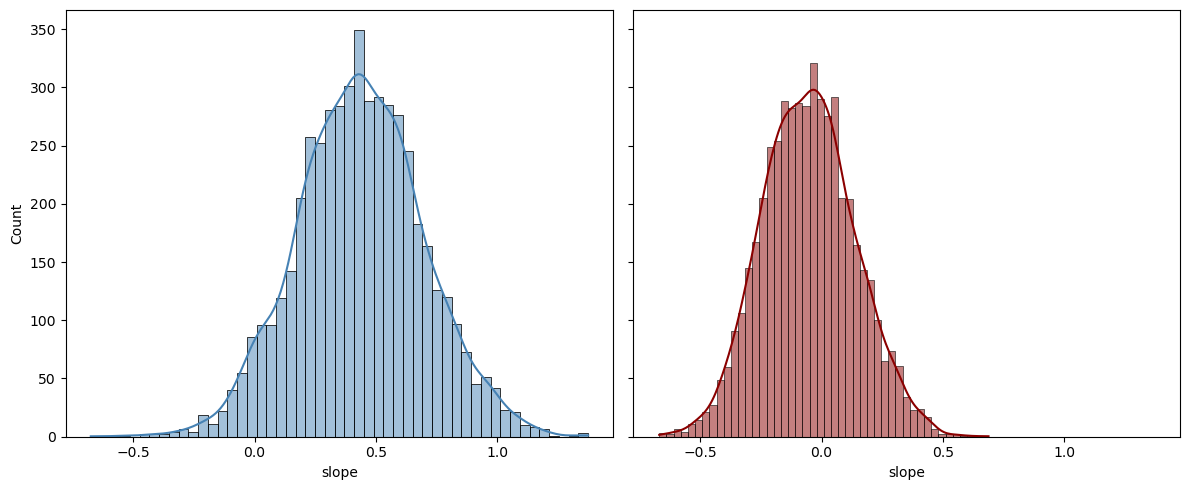

Bootstrap caso sperimentale: 95.2% dei campioni ha slope > 0
Bootstrap caso sanity check: 38.7% dei campioni ha slope > 0


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5),sharex=True, sharey=True)

sns.histplot(slopes_boot, kde=True, ax=axes[0], color='steelblue')
#axes[0].set_title('Bootstrap - distribuzione slope')
axes[0].set_xlabel('slope')
#axes[0].axvline(slopes_boot, color='red', linestyle='--', label='slope su tutti i dati')
#axes[0].legend()

sns.histplot(slopes_boot_sc, kde=True, ax=axes[1], color='darkred')
#axes[1].set_title('')
axes[1].set_xlabel('slope')
#axes[1].axvline(slopes_boot_sc, color='red', linestyle='--', label='slope su tutti i dati')
#axes[1].legend()

plt.tight_layout()
plt.show()

frac_sopra_0_boot = np.mean(slopes_boot > 0)
frac_sopra_0_boot_sc = np.mean(slopes_boot_sc > 0)
print(f"Bootstrap caso sperimentale: {frac_sopra_0_boot*100:.1f}% dei campioni ha slope > 0")
print(f"Bootstrap caso sanity check: {frac_sopra_0_boot_sc*100:.1f}% dei campioni ha slope > 0")


In [52]:
# Altro metodo gia' implementato in stats
from scipy.stats import bootstrap


data = (x_arr, y_arr)

res = bootstrap(
    data,
    statistic=lambda x, y: np.polyfit(x, y, 1)[0],  # slope
    n_resamples=5000,
    paired=True,          # importante: x e y devono essere ricampionati insieme (stessi indici)
    confidence_level=0.95,
    method='percentile',  # o 'basic', 'BCa'
    random_state=42
)

print("CI 95%:", res.confidence_interval)
print("std error:", res.standard_error)
slopes_boot_2 = res.bootstrap_distribution 

CI 95%: ConfidenceInterval(low=np.float64(-0.04588752878582935), high=np.float64(0.9885298913875012))
std error: 0.26025827298738674


In [27]:
data_sc = (x_sc_arr, y_sc_arr)

res_sc = bootstrap(
    data_sc,
    statistic=lambda x, y: np.polyfit(x, y, 1)[0],  # slope
    n_resamples=5000,
    paired=True,          # importante: x e y devono essere ricampionati insieme (stessi indici)
    confidence_level=0.95,
    method='percentile',  # o 'basic', 'BCa'
    random_state=42
)
slopes_boot_sc_2 = res_sc.bootstrap_distribution

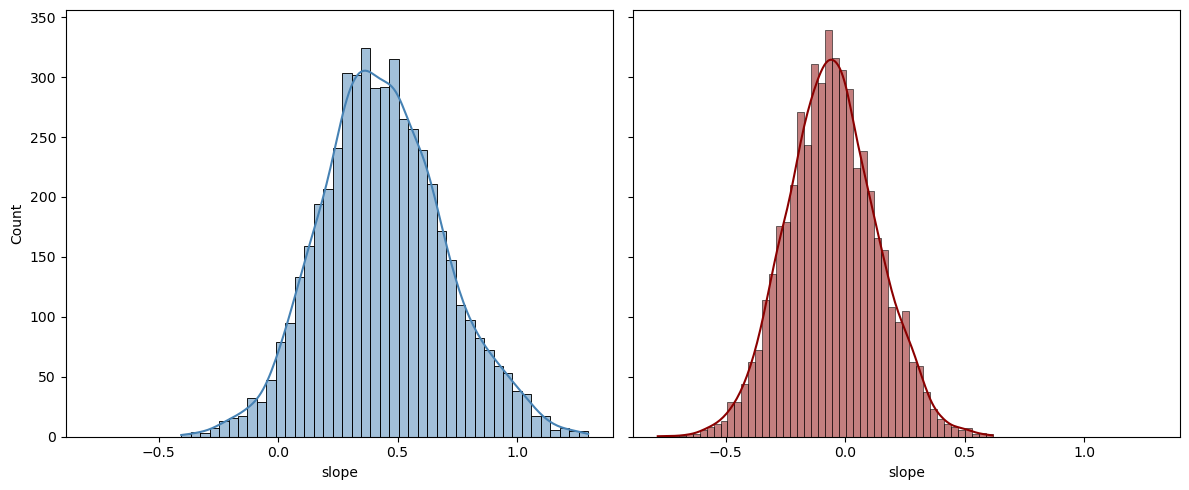

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5),sharex=True, sharey=True)

sns.histplot(slopes_boot_2, kde=True, ax=axes[0], color='steelblue')
#axes[0].set_title('Bootstrap - distribuzione slope')
axes[0].set_xlabel('slope')
#axes[0].axvline(slopes_boot, color='red', linestyle='--', label='slope su tutti i dati')
#axes[0].legend()

sns.histplot(slopes_boot_sc_2, kde=True, ax=axes[1], color='darkred')
#axes[1].set_title('')
axes[1].set_xlabel('slope')
#axes[1].axvline(slopes_boot_sc, color='red', linestyle='--', label='slope su tutti i dati')
#axes[1].legend()

plt.tight_layout()
plt.show()

### Slope calcolata da y=mx anziche' come in precedenza (y = mx + q)


In [41]:
def function(x, y):
    slope = np.sum(x * y) / np.sum(x ** 2)
    return slope

In [42]:
# Bootstrap
x_arr = np.asarray(x_arr, dtype=np.float64)
y_arr = np.asarray(y_arr, dtype=np.float64)
x_sc_arr = np.asarray(x_sc_arr, dtype=np.float64)
y_sc_arr = np.asarray(y_sc_arr, dtype=np.float64)

from scipy.stats import linregress

def bootstrap_slopes_constr(x, y, N=1000, seed=None):
    """
    x, y: array di punti (stessa lunghezza)
    N: numero di campioni bootstrap
    Ritorna: array di N slopes
    """

    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    rng = np.random.default_rng(seed)
    n = len(x)
    slopes = [] # np.empty(N)

    for i in range(N):
        idx = rng.integers(0, n, size=n)  # genera n numeri interi casuali tra 0 e n-1, con la possibilita' di prendere numeri ripetuti


        slope = function(x[idx],y[idx])


        slopes.append(slope)

    slopes = np.array(slopes)
    return slopes


In [43]:
slopes_boot_3 = bootstrap_slopes_constr(x_arr, y_arr, N=5000, seed=2)
slopes_boot_sc_3 = bootstrap_slopes_constr(x_sc_arr, y_sc_arr, N=5000, seed=2)

print(slopes_boot_sc_3)

[-0.15873887  0.10116227  0.18897509 ... -0.13703884 -0.25461617
 -0.06250404]


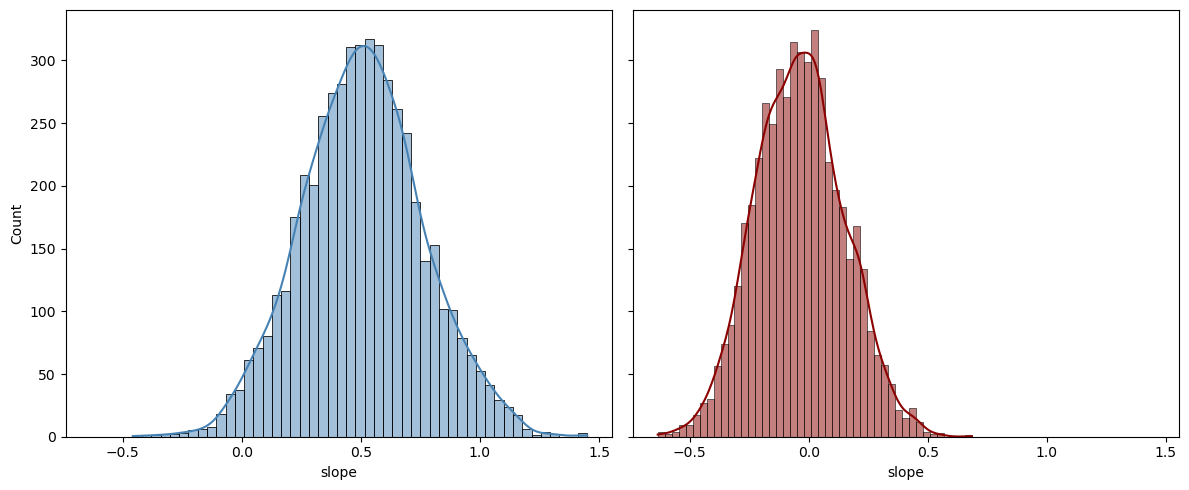

In [44]:

#import matplotlib.pyplot as plt
#import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5),sharex=True, sharey=True)

sns.histplot(slopes_boot_3, kde=True, ax=axes[0], color='steelblue')
#axes[0].set_title('Bootstrap - distribuzione slope')
axes[0].set_xlabel('slope')
#axes[0].axvline(slopes_boot, color='red', linestyle='--', label='slope su tutti i dati')
#axes[0].legend()

sns.histplot(slopes_boot_sc_3, kde=True, ax=axes[1], color='darkred')
#axes[1].set_title('')
axes[1].set_xlabel('slope')
#axes[1].axvline(slopes_boot_sc, color='red', linestyle='--', label='slope su tutti i dati')
#axes[1].legend()

plt.tight_layout()
plt.show()